In [3]:
import pandas as pd
import matplotlib.pyplot as plt

verificamos que cantidades de input red sean iguales a cantidades disponibles en el excel- ok

verificamos que la demanda remanente para termicas sea el despacho que dan las termicas - ligeras discrepancias que corrijo con la demanda programada ok

verificamos que el bid que dan las termicas en input red sea el bid que dan las termicas en precios declarados - ok


verificar que las cantidades de eq de npga para cada planta sean cantidades de equilibrio de despacho programado- pendiente

verificar que el sampling lo haga bien porfa, o sea sin repeticion, y que me escoja primero bids mas bartos y asi

In [ ]:
#Los valores están en el rango esperado para plantas térmicas en Colombia (~700 MW – 1.2 GW por hora)

## Mi equilibrio

In [4]:
CSV_PATH = "../../results/fechas_117/TERMICA/inputRed.csv"   # <-- adjust
input_red = pd.read_csv(
    CSV_PATH,
    sep=";",
    decimal=",",      # 817128,3029 -> 817128.3029
    thousands="."     # si tienes 1.234.567,89
)

input_red.head()

,CodigoPlanta,available_q,phi,precio_d,daily_reman_demand,Fecha,cluster,id_planta
0,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...",0.0,11.27,"[126600.0, 77740.0, 137720.0, 521300.0, 114130...",2025-08-05,12.0,1
1,TYP2,"[22000.0, 22000.0, 22000.0, 22000.0, 22000.0, ...",0.0,11.27,"[126600.0, 77740.0, 137720.0, 521300.0, 114130...",2025-08-05,12.0,2
2,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...",0.0,91.94,"[857700.0, 845560.0, 650860.0, 553730.0, 70115...",2025-09-02,12.0,1
3,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...",0.0,91.94,"[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,12.0,1
4,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...",0.0,91.94,"[487560.0, 261410.0, 324070.0, 304360.0, 36979...",2025-09-04,9.0,1


In [5]:
input_red = input_red.sort_values(by=['Fecha', 'CodigoPlanta'], ascending=[True, True]).reset_index(drop=True)
input_red

,CodigoPlanta,available_q,phi,precio_d,daily_reman_demand,Fecha,cluster,id_planta
0,3ENA,"[200000.0, 200000.0, 200000.0, 200000.0, 20000...",830.944358,889.28,"[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,10.0,29
1,CTG1,"[52000.0, 52000.0, 52000.0, 52000.0, 52000.0, ...",1700.473455,1727.79,"[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,10.0,27
2,CTG2,"[57000.0, 57000.0, 57000.0, 57000.0, 57000.0, ...",1604.550129,1637.40,"[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,10.0,28
3,GE32,"[255000.0, 255000.0, 255000.0, 255000.0, 25500...",217.325506,288.92,"[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,10.0,9
4,GEC3,"[164000.0, 164000.0, 164000.0, 164000.0, 16400...",223.180461,272.23,"[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,10.0,13
...,...,...,...,...,...,...,...,...
4207,TYP4,"[255000.0, 255000.0, 255000.0, 255000.0, 25500...",36.653367,288.95,"[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,NaN,8
4208,ZPA2,"[36000.0, 36000.0, 36000.0, 36000.0, 36000.0, ...",312.774255,372.94,"[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,12.0,15
4209,ZPA3,"[63000.0, 63000.0, 63000.0, 63000.0, 63000.0, ...",265.226282,346.94,"[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,12.0,17
4210,ZPA4,"[64000.0, 64000.0, 64000.0, 64000.0, 64000.0, ...",254.062262,360.94,"[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,12.0,26


In [17]:
codigo_termicas=input_red['CodigoPlanta'].unique()

## Equilibrio Observado

In [ ]:
disponible = pd.read_csv('../../datos/raw/Disponibilidadcomercialporplantajulio.csv', sep=',')


In [ ]:
import pandas as pd

def procesar_disponibilidad(path_csv, codigo_termicas, version='TX4'):
    """
    Lee archivo de disponibilidad y devuelve DataFrame con:
    CodigoPlanta | Fecha | quantities (lista de 24 valores)
    """

    # Leer archivo
    disponible = pd.read_csv(path_csv, sep=',')

    # Filtrar versión
    
    disponible = disponible[disponible['Version'] == version]

    # Filtrar plantas
    disponible = disponible[disponible['CodigoPlanta'].isin(codigo_termicas)]

    # Convertir fecha
    disponible['FechaHora'] = pd.to_datetime(disponible['FechaHora'])

    # Extraer fecha y hora
    disponible['Fecha'] = disponible['FechaHora'].dt.date
    disponible['Hora'] = disponible['FechaHora'].dt.hour

    # Pivot por hora
    pivot_horas = disponible.pivot_table(
        index=['CodigoPlanta', 'Fecha'],
        columns='Hora',
        values='Valor',
        fill_value=0
    )

    # Asegurar 24 horas (0–23)
    pivot_horas = pivot_horas.reindex(columns=range(24), fill_value=0)

    # Convertir cada fila en lista
    pivot_horas['quantities'] = pivot_horas.apply(lambda row: row.tolist(), axis=1)

    # Formato final
    result = pivot_horas.reset_index()[['CodigoPlanta', 'Fecha', 'quantities']]

    # Ordenar por Fecha y CodigoPlanta
    result = result.sort_values(
        by=['Fecha', 'CodigoPlanta'],
        ascending=[True, True]
    ).reset_index(drop=True)

    return result

In [59]:
df1 = procesar_disponibilidad(
    '../../datos/raw/Disponibilidadcomercialporplantajulio.csv',
    codigo_termicas
)

df2 = procesar_disponibilidad(
    '../../datos/raw/Disponibilidadcomercialporplantaseptiembre.csv',
    codigo_termicas,version='TX1'
)

# Luego los puedes pegar
disponibilidad = pd.concat([df1, df2], ignore_index=True)

## 1.verificamos que cantidades de input red sean iguales a cantidades disponibles en el excel

In [61]:
disponibilidad

Hora,CodigoPlanta,Fecha,quantities
0,3ENA,2025-04-01,"[200000.0, 200000.0, 200000.0, 200000.0, 20000..."
1,CTG1,2025-04-01,"[52000.0, 52000.0, 52000.0, 52000.0, 52000.0, ..."
2,CTG2,2025-04-01,"[57000.0, 57000.0, 57000.0, 57000.0, 57000.0, ..."
3,GE32,2025-04-01,"[255000.0, 255000.0, 255000.0, 255000.0, 25500..."
4,GEC3,2025-04-01,"[164000.0, 164000.0, 164000.0, 164000.0, 16400..."
...,...,...,...
2790,TYP2,2025-09-02,"[27000.0, 27000.0, 27000.0, 27000.0, 27000.0, ..."
2791,TYP3,2025-09-02,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ..."
2792,ZPA2,2025-09-02,"[36000.0, 36000.0, 36000.0, 36000.0, 36000.0, ..."
2793,ZPA3,2025-09-02,"[63000.0, 63000.0, 63000.0, 63000.0, 63000.0, ..."


despacho

In [12]:
despacho = pd.read_csv('../../datos/raw/Despachoprogramadorecursosdegeneracion.csv', sep=',')


# Asegurarse que FechaHora es datetime
despacho["FechaHora"] = pd.to_datetime(despacho["FechaHora"])

# Extraer Fecha y Hora
despacho["Fecha"] = despacho["FechaHora"].dt.date
despacho["Hora"] = despacho["FechaHora"].dt.hour

# Pivotear: filas por CodigoPlanta y Fecha, columnas = Hora
df_pivot = despacho.pivot_table(
    index=["CodigoElementoGeneracion", "Fecha"],  # si "CodigoPlanta" es "CodigoElementoGeneracion"
    columns="Hora",
    values="Valor",
    fill_value=0  # rellena con 0 donde falte
)

# Reindexar columnas para asegurar 0-23
df_pivot = df_pivot.reindex(columns=range(24), fill_value=0)

# Crear columna array con los 24 valores
df_pivot["quantities"] = df_pivot.values.tolist()

# Resetear índice si quieres un df limpio
final_df = df_pivot.reset_index()[["CodigoElementoGeneracion", "Fecha", "quantities"]]

# Renombrar columna si quieres
final_df = final_df.rename(columns={"CodigoElementoGeneracion": "CodigoPlanta"})

print(final_df.head())


Hora CodigoPlanta       Fecha  \
0            2QBW  2025-04-01   
1            2QBW  2025-04-02   
2            2QBW  2025-04-03   
3            2QBW  2025-04-04   
4            2QBW  2025-04-05   

Hora                                         quantities  
0     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
1     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
2     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
3     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
4     [8000.0, 8000.0, 8000.0, 8000.0, 8000.0, 8000....  


## termicas, hidraulicas y solares

In [129]:
#### tipo generador
tipo = pd.read_csv("../../results/fechas_117/plantas_tipo.csv") #cambiar la direccion
tipo['Tipo Generación'].value_counts()


Tipo Generación
TERMICA       36
HIDRAULICA    30
SOLAR         10
Name: count, dtype: int64

In [207]:
df_desglose = pd.read_excel("../../datos/raw/desglose.xlsx",header=3)
df_desglose[["Código SIC", "Tipo Generación"]]

,Código SIC,Tipo Generación
0,5E69,TERMICA
1,4YCN,TERMICA
2,4XP3,TERMICA
3,4T6C,TERMICA
4,3NNZ,TERMICA
...,...,...
502,ILC1,COGENERADOR
503,CIP1,COGENERADOR
504,PPN1,COGENERADOR
505,CAS1,COGENERADOR


In [104]:
despacho = pd.read_csv('../../datos/raw/Despachoprogramadorecursosdegeneracion.csv', sep=',')
despacho

,FechaHora,CodigoDuracion,CodigoElementoGeneracion,Valor
0,2025-08-11 00:00:00,PT1H,2QBW,18380
1,2025-08-11 00:00:00,PT1H,2QEK,35000
2,2025-08-11 00:00:00,PT1H,2QRL,650
3,2025-08-11 00:00:00,PT1H,2QV2,6000
4,2025-08-11 00:00:00,PT1H,2R22,18000
...,...,...,...,...
1264514,2025-04-05 23:00:00,PT1H,SLVJ,95000
1264515,2025-04-05 23:00:00,PT1H,SMI1,25000
1264516,2025-04-05 23:00:00,PT1H,SNC1,700
1264517,2025-04-05 23:00:00,PT1H,SNCR,729000


In [ ]:
despacho = despacho.merge(
    tipo[["CodigoPlanta", "Tipo Generación"]],
    left_on="CodigoElementoGeneracion",
    right_on="CodigoPlanta",
    how="left"
)

In [133]:
despacho

,FechaHora,CodigoDuracion,CodigoElementoGeneracion,Valor,CodigoPlanta,Tipo Generación,Hora
0,2025-08-11 00:00:00,PT1H,2QBW,18380,NaN,NaN,0
1,2025-08-11 00:00:00,PT1H,2QEK,35000,2QEK,HIDRAULICA,0
2,2025-08-11 00:00:00,PT1H,2QRL,650,NaN,NaN,0
3,2025-08-11 00:00:00,PT1H,2QV2,6000,NaN,NaN,0
4,2025-08-11 00:00:00,PT1H,2R22,18000,NaN,NaN,0
...,...,...,...,...,...,...,...
1264514,2025-04-05 23:00:00,PT1H,SLVJ,95000,SLVJ,HIDRAULICA,23
1264515,2025-04-05 23:00:00,PT1H,SMI1,25000,SMI1,HIDRAULICA,23
1264516,2025-04-05 23:00:00,PT1H,SNC1,700,NaN,NaN,23
1264517,2025-04-05 23:00:00,PT1H,SNCR,729000,SNCR,HIDRAULICA,23


In [205]:
despacho['CodigoElementoGeneracion'].unique()

<StringArray>
['2QBW', '2QEK', '2QRL', '2QV2', '2R22', '2S6U', '2S78', '2S8I', '2S8N',
 '2S8S',
 ...
 '3RKN', '3RKP', '4QPJ', 'ERRG', 'GNYG', 'ISGG', '4UZM', '4XQ2', '4ZIO',
 '4YAW']
Length: 418, dtype: str

In [208]:
despacho

,FechaHora,CodigoDuracion,CodigoElementoGeneracion,Valor,CodigoPlanta,Tipo Generación,Hora,Date,Hour
0,2025-08-11 00:00:00,PT1H,2QBW,18380,NaN,NaN,0,2025-08-11,0
1,2025-08-11 00:00:00,PT1H,2QEK,35000,2QEK,HIDRAULICA,0,2025-08-11,0
2,2025-08-11 00:00:00,PT1H,2QRL,650,NaN,NaN,0,2025-08-11,0
3,2025-08-11 00:00:00,PT1H,2QV2,6000,NaN,NaN,0,2025-08-11,0
4,2025-08-11 00:00:00,PT1H,2R22,18000,NaN,NaN,0,2025-08-11,0
...,...,...,...,...,...,...,...,...,...
1264514,2025-04-05 23:00:00,PT1H,SLVJ,95000,SLVJ,HIDRAULICA,23,2025-04-05,23
1264515,2025-04-05 23:00:00,PT1H,SMI1,25000,SMI1,HIDRAULICA,23,2025-04-05,23
1264516,2025-04-05 23:00:00,PT1H,SNC1,700,NaN,NaN,23,2025-04-05,23
1264517,2025-04-05 23:00:00,PT1H,SNCR,729000,SNCR,HIDRAULICA,23,2025-04-05,23


In [214]:
despacho[despacho['CodigoPlanta'].isnull()]

,FechaHora,CodigoDuracion,CodigoElementoGeneracion,Valor,CodigoPlanta,Tipo Generación,Hora,Date,Hour
0,2025-08-11 00:00:00,PT1H,2QBW,18380,NaN,NaN,0,2025-08-11,0
2,2025-08-11 00:00:00,PT1H,2QRL,650,NaN,NaN,0,2025-08-11,0
3,2025-08-11 00:00:00,PT1H,2QV2,6000,NaN,NaN,0,2025-08-11,0
4,2025-08-11 00:00:00,PT1H,2R22,18000,NaN,NaN,0,2025-08-11,0
5,2025-08-11 00:00:00,PT1H,2S6U,6500,NaN,NaN,0,2025-08-11,0
...,...,...,...,...,...,...,...,...,...
1264510,2025-04-05 23:00:00,PT1H,SJM1,0,NaN,NaN,23,2025-04-05,23
1264511,2025-04-05 23:00:00,PT1H,SJN1,0,NaN,NaN,23,2025-04-05,23
1264512,2025-04-05 23:00:00,PT1H,SJOG,190,NaN,NaN,23,2025-04-05,23
1264513,2025-04-05 23:00:00,PT1H,SLV1,340,NaN,NaN,23,2025-04-05,23


In [ ]:
despacho_diario_total = despacho.groupby('Fecha')['Valor'].sum().reset_index()
despacho_diario_total.rename(columns={'Valor':'ValorTotal'}, inplace=True)

print(despacho_diario_total.head())

In [212]:
despacho[despacho['CodigoPlanta'].isnull()]['CodigoElementoGeneracion'].unique().tolist()  

['2QBW',
 '2QRL',
 '2QV2',
 '2R22',
 '2S6U',
 '2S78',
 '2S8I',
 '2S8N',
 '2S8S',
 '2S8U',
 '2S9L',
 '2SDR',
 '2SI1',
 '2SS2',
 '2SW1',
 '2T1L',
 '2T4P',
 '2T7D',
 '2TUT',
 '2TUV',
 '2TYI',
 '2U1G',
 '2U8Y',
 '2U91',
 '2U93',
 '2UP2',
 '2UPD',
 '2UPF',
 '2UPH',
 '2UPJ',
 '2UR5',
 '2UX3',
 '2V25',
 '2V27',
 '2V5G',
 '2VJS',
 '2WC5',
 '2WFN',
 '2YB9',
 '2YIR',
 '2YNA',
 '2YWY',
 '2ZCF',
 '2ZHY',
 '2ZP9',
 '3A44',
 '3ACC',
 '3ADA',
 '3AFQ',
 '3AQP',
 '3B4L',
 '3BZB',
 '3C3X',
 '3C3Z',
 '3C4V',
 '3CG9',
 '3CSH',
 '3DSO',
 '3DXJ',
 '3E7C',
 '3E9I',
 '3EBN',
 '3EDL',
 '3EE4',
 '3EFY',
 '3ENE',
 '3EP6',
 '3EV1',
 '3EV3',
 '3EXB',
 '3EXH',
 '3F5L',
 '3F5N',
 '3FCD',
 '3FCF',
 '3GI6',
 '3GJQ',
 '3GJU',
 '3GPZ',
 '3GRD',
 '3GSF',
 '3GVI',
 '3GVK',
 '3GVM',
 '3H2U',
 '3HBN',
 '3HBP',
 '3HDE',
 '3HDG',
 '3HE8',
 '3HF7',
 '3HF9',
 '3HG7',
 '3HLD',
 '3HS9',
 '3HWM',
 '3HYG',
 '3IRZ',
 '3IS2',
 '3J1J',
 '3J2B',
 '3J2H',
 '3J4D',
 '3J4R',
 '3J4T',
 '3J4V',
 '3J83',
 '3J85',
 '3JBP',
 '3JP6',
 '3JP8',
 

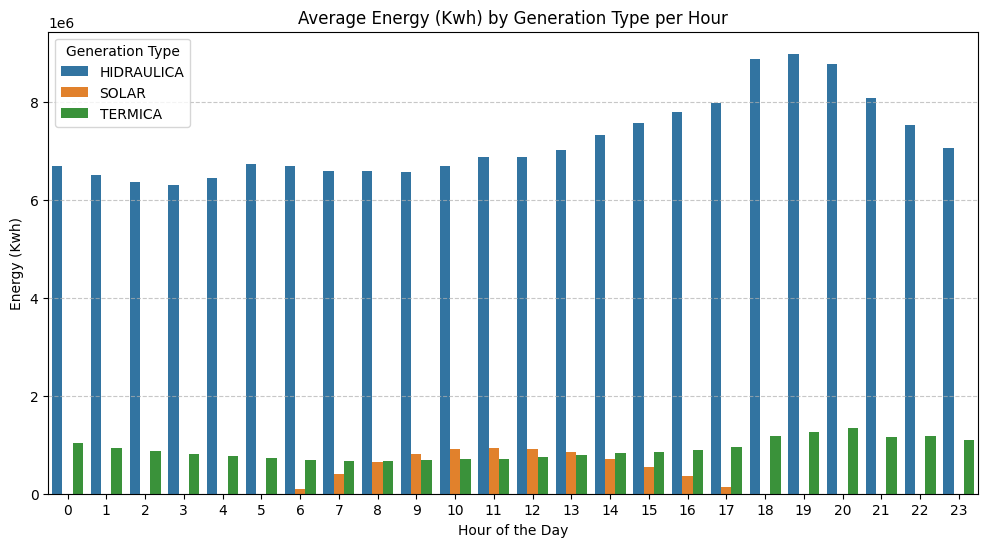

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Ensure FechaHora is datetime
despacho["FechaHora"] = pd.to_datetime(despacho["FechaHora"])

# Extract date and hour
despacho["Date"] = despacho["FechaHora"].dt.date
despacho["Hour"] = despacho["FechaHora"].dt.hour

# Step 1: Sum Valor for each Date and Generation Type at each Hour
df_daily = despacho.groupby(["Date", "Tipo Generación", "Hour"])["Valor"].sum().reset_index()

# Step 2: Compute mean across all Dates for each Hour and Generation Type
df_plot = df_daily.groupby(["Tipo Generación", "Hour"])["Valor"].mean().reset_index()

# Plot grouped bar chart
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_plot,
    x="Hour",
    y="Valor",
    hue="Tipo Generación"
)

plt.title("Average Energy (Kwh) by Generation Type per Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Energy (Kwh)")
plt.xticks(range(0,24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Generation Type")
plt.show()

In [ ]:
## esto esta bien coincide con los valores de la pagina https://www.xm.com.co/generaci%C3%B3n/informes-despacho/despacho-nacional, mira blob:https://www.xm.com.co/b38fbfc7-54eb-41f3-9c0d-962cd2f0be48

In [217]:
despacho_diario_total = despacho.groupby('Date')['Valor'].sum().reset_index()
despacho_diario_total.rename(columns={'Valor':'ValorTotal'}, inplace=True)

print(despacho_diario_total.head())

         Date  ValorTotal
0  2025-04-01   231947160
1  2025-04-02   231518930
2  2025-04-03   230498930
3  2025-04-04   227982000
4  2025-04-05   217050520


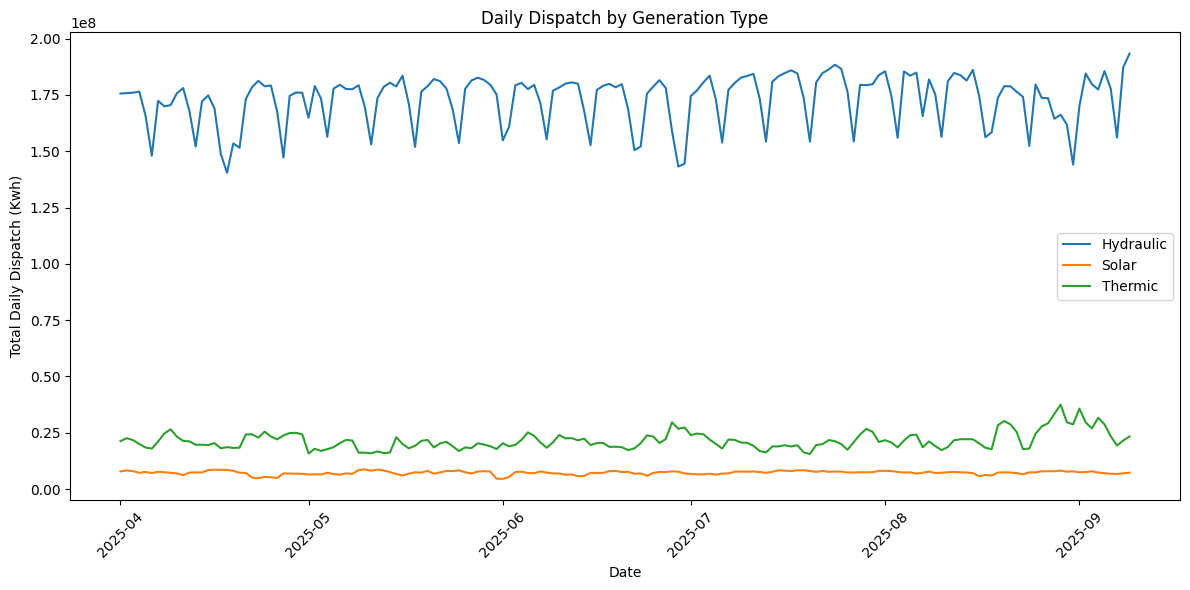

In [232]:
despacho_diario_tipo = despacho.groupby(['Date', 'Tipo Generación'])['Valor'].sum().reset_index()
despacho_diario_tipo.rename(columns={'Valor':'ValorTotal'}, inplace=True)

pivot_diario = despacho_diario_tipo.pivot(
    index='Date',
    columns='Tipo Generación',
    values='ValorTotal'
)

import matplotlib.pyplot as plt

# Renaming the generation types for clearer labels
pivot_diario.columns = ['Hydraulic', 'Solar', 'Thermic']  # adjust to your actual column names

# Create figure
plt.figure(figsize=(12,6))

# Plot each generation type as a separate line
for tipo in pivot_diario.columns:
    plt.plot(pivot_diario.index, pivot_diario[tipo], label=tipo)

# Labels and title
plt.xlabel('Date')
plt.ylabel('Total Daily Dispatch (Kwh)')
plt.title('Daily Dispatch by Generation Type')

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#186 GW=186,000,000 kW y 175,000,000 kw

In [ ]:
#1 GW = 1,000,000 kWh
#en promedio el país consume electricidad cerca de ~9–10 GW de potencia instantánea en cualquier hora promedio del año.

In [244]:
import requests
import pandas as pd

codes = [
 '2QBW','2QRL','2QV2','2R22','2S6U','2S78','2S8I','2S8N','2S8S','2S8U','2S9L','2SDR','2SI1','2SS2','2SW1',
 '2T1L','2T4P','2T7D','2TUT','2TUV','2TYI','2U1G','2U8Y','2U91','2U93','2UP2','2UPD','2UPF','2UPH','2UPJ',
 '2UR5','2UX3','2V25','2V27','2V5G','2VJS','2WC5','2WFN','2YB9','2YIR','2YNA','2YWY','2ZCF','2ZHY','2ZP9',
 '3A44','3ACC','3ADA','3AFQ','3AQP','3B4L','3BZB','3C3X','3C3Z','3C4V','3CG9','3CSH','3DSO','3DXJ','3E7C',
 '3E9I','3EBN','3EDL','3EE4','3EFY','3ENE','3EP6','3EV1','3EV3','3EXB','3EXH','3F5L','3F5N','3FCD','3FCF',
 '3GI6','3GJQ','3GJU','3GPZ','3GRD','3GSF','3GVI','3GVK','3GVM','3H2U','3HBN','3HBP','3HDE','3HDG','3HE8',
 '3HF7','3HF9','3HG7','3HLD','3HS9','3HWM','3HYG','3IRZ','3IS2','3J1J','3J2B','3J2H','3J4D','3J4R','3J4T',
 '3J4V','3J83','3J85','3JBP','3JP6','3JP8','3JPA','3JPC','3JPE','3JPK','3JPM','3JQA','3JQC','3JQE','3K6T',
 '3K6X','3K8A','3K8C','3K8E','3KJK','3KL4','3KLQ','3KOL','3L9B','3LLY','3LMH','3LMJ','3MHB','3MS2','3NDE',
 '3NGJ','3NLE','3NLG','3NLZ','3NNZ','3NR4','3NR8','3NU4','3PK3','3PKF','3PWF','3PXC','3PXE','3PXF','3PXH',
 'TR2G','TR3G','TUJ1','UNN1','USQ1','VLT1','VNTB','3Q87','3Q89','3Q99','3Q9K','3QCI','3QPE','3QQ3','3R9G',
 '3RGX','3RGZ','3RH2','4RGG','4RMR','4S1G','4S66','4S7E','4S7I','4S7K','4SO2','4SO4','4SO8','4SS7','4T6C',
 '4T9M','4ULO','4ULS','4ULY','4UM1','4UZS','4UZU','4VBC','4VYB','4VYM','4WP2','4WUK','4WUM','4WWQ','4WWY',
 '4XP3','4XQA','4XQC','4Y5T','4YCF','4YL2','4YL8','4YLK','4YLM','4YLO','4Z9Q','4Z9S','ABJ1','AFR1','ALTG',
 'AMA1','AMF1','AMR1','ASN1','AYR1','BAR1','BLL3','BLM1','BSQ1','CAS1','CCN1','CGM1','CIP1','CIS1','CLDR',
 'CMN1','COE1','CQT1','CRC1','CSC1','FLRD','GCA1','GQA1','HMO1','HRD1','INC1','INS1','IRG1','LCS1','LMR1',
 'LPLO','MIR1','MND1','NAV1','NIM1','NQU1','OVJ1','PJR1','PLU1','PMR1','PNC1','PRD4','PRV1','PST1','PTA1',
 'PTC1','PTG1','RBB1','RCIO','RFR1','RFR2','RMR1','RMYO','RNG1','RPD1','RPL1','SBA1','SFC1','SLV1','SNC1',
 'SNT1','SPY1','SRA1','STG1','SUV1','TMS1','TPD1','GCC1','LBR1','RGR1','SJOG','2S6S','3IJF','CMP2','MNC1',
 'PLM1','RGRN','3ED1','3KVZ','3KXQ','3Q7D','3QK6','4RG6','CTG3','CUR1','ECU1','ECU2','INT1','INZ1','IQU1',
 'IQU2','SJM1','SJN1','SNS1','TCBE','TMB1','TYP5','VNTA','2S6Q','2S9Q','2SXQ','2U5P','2XXR','3HG9','3JNR',
 '4T6E','ARG1','BYN1','CPT1','MNT1','NTB1','RCL1','4YCN','4YLA','4ZEP','4ZIS','54091','5AD4','GYP3','4SNT',
 '4SO6','3PXJ','3RKN','3RKP','4QPJ','ERRG','GNYG','ISGG','4UZM','4XQ2','4ZIO','4YAW'
]

# 1) Descargar “ListadoRecursos” (XM API)
url = "https://servapibi.xm.com.co/lists"
payload = {"MetricId": "ListadoRecursos"}  # métrica de listado de recursos con atributos
r = requests.post(url, json=payload, timeout=60)
r.raise_for_status()
raw = r.json()

# 2) Normalizar a DataFrame (estructura puede variar)
if isinstance(raw, dict):
    records = raw.get("Items") or raw.get("items") or raw.get("Data") or raw.get("data") or raw
    if isinstance(records, dict):
        # a veces viene anidado
        records = records.get("Items") or records.get("items") or records.get("Data") or records.get("data") or []
else:
    records = raw

df = pd.json_normalize(records)
df['ListEntities'].get(2)

[{'Id': 'Sistema',
  'Values': {'Code': '2QRL',
   'Name': 'LA REBUSCA',
   'Type': 'HIDRAULICA',
   'Disp': 'NO DESPACHADO CENTRALMENTE',
   'RecType': 'GEN. DISTRIBUIDA',
   'CompanyCode': 'HZEG',
   'EnerSource': 'AGUA',
   'OperStartdate': '2014-07-24',
   'State': 'OPERACION'}}]

precio horario

In [102]:

precio_horario = pd.read_csv('../../datos/raw/Preciodebolsahorario.csv')
filtro = (precio_horario['CodigoVariable'] == 'PB_Int') & (precio_horario['Version'] == 'TXF')
precio_horario = precio_horario[filtro]

In [267]:
precio_horario.sort_values(by=['FechaHora'], ascending=True, inplace=True)

In [268]:
precio_horario

,CodigoVariable,FechaHora,CodigoDuracion,UnidadMedida,Version,Valor
4248,PB_Int,2025-04-01 00:00:00,PT1H,COP/kWh,TXF,162.38
4249,PB_Int,2025-04-01 01:00:00,PT1H,COP/kWh,TXF,162.38
4250,PB_Int,2025-04-01 02:00:00,PT1H,COP/kWh,TXF,162.38
4251,PB_Int,2025-04-01 03:00:00,PT1H,COP/kWh,TXF,162.38
4252,PB_Int,2025-04-01 04:00:00,PT1H,COP/kWh,TXF,162.38
...,...,...,...,...,...,...
9019,PB_Int,2025-09-09 19:00:00,PT1H,COP/kWh,TXF,875.07
9020,PB_Int,2025-09-09 20:00:00,PT1H,COP/kWh,TXF,875.07
9021,PB_Int,2025-09-09 21:00:00,PT1H,COP/kWh,TXF,255.14
9022,PB_Int,2025-09-09 22:00:00,PT1H,COP/kWh,TXF,110.67


Bids

In [18]:
cantidades_eq = pd.read_csv('../../datos/raw/Despachoprogramadorecursosdegeneracion.csv', sep=',')

In [19]:
cantidades_eq

,FechaHora,CodigoDuracion,CodigoElementoGeneracion,Valor
0,2025-08-11 00:00:00,PT1H,2QBW,18380
1,2025-08-11 00:00:00,PT1H,2QEK,35000
2,2025-08-11 00:00:00,PT1H,2QRL,650
3,2025-08-11 00:00:00,PT1H,2QV2,6000
4,2025-08-11 00:00:00,PT1H,2R22,18000
...,...,...,...,...
1264514,2025-04-05 23:00:00,PT1H,SLVJ,95000
1264515,2025-04-05 23:00:00,PT1H,SMI1,25000
1264516,2025-04-05 23:00:00,PT1H,SNC1,700
1264517,2025-04-05 23:00:00,PT1H,SNCR,729000


In [20]:
cantidades_eq=cantidades_eq[cantidades_eq['CodigoElementoGeneracion'].isin(codigo_termicas)]

# Asegurarse que FechaHora es datetime
cantidades_eq["FechaHora"] = pd.to_datetime(cantidades_eq["FechaHora"])

# Extraer Fecha y Hora
cantidades_eq["Fecha"] = cantidades_eq["FechaHora"].dt.date
cantidades_eq["Hora"] = cantidades_eq["FechaHora"].dt.hour

# Pivotear: filas por CodigoPlanta y Fecha, columnas = Hora
df_pivot = cantidades_eq.pivot_table(
    index=["CodigoElementoGeneracion", "Fecha"],  # si "CodigoPlanta" es "CodigoElementoGeneracion"
    columns="Hora",
    values="Valor",
    fill_value=0  # rellena con 0 donde falte
)

# Reindexar columnas para asegurar 0-23
df_pivot = df_pivot.reindex(columns=range(24), fill_value=0)

# Crear columna array con los 24 valores
df_pivot["eq_quantities"] = df_pivot.values.tolist()

# Resetear índice si quieres un df limpio
final_df = df_pivot.reset_index()[["CodigoElementoGeneracion", "Fecha", "eq_quantities"]]
final_df = final_df.sort_values(
        by=['Fecha', 'CodigoElementoGeneracion'],
        ascending=[True, True]
    ).reset_index(drop=True)

eto es para verificar despues de correr el npga

In [21]:
final_df

Hora,CodigoElementoGeneracion,Fecha,eq_quantities
0,3ENA,2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,CTG1,2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,CTG2,2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,GE32,2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,GEC3,2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...
2498,TGJ1,2025-09-09,"[101000.0, 145000.0, 145000.0, 141560.0, 14500..."
2499,TRN1,2025-09-09,"[62000.0, 62000.0, 62000.0, 62000.0, 62000.0, ..."
2500,TYP2,2025-09-09,"[27000.0, 27000.0, 27000.0, 27000.0, 27000.0, ..."
2501,TYP3,2025-09-09,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ..."


## Pero esto sí nos permite ver el input red


## 2.verificamos que la demanda remanente para termicas sea el despacho que dan las termicas

In [22]:
## esto recibe el despacho promegramado

import numpy as np
import pandas as pd

def sumar_por_fecha(df):
    """
    Recibe DataFrame con columnas:
    Fecha | eq_quantities (lista de 24)
    
    Devuelve:
    Fecha | total_quantities (lista de 24 sumadas)
    """

    result = (
        df
        .groupby('Fecha')['eq_quantities']
        .apply(lambda x: np.sum(np.vstack(x), axis=0))
        .reset_index()
    )

    # Convertir arrays numpy a listas (opcional)
    result['total_quantities'] = result['eq_quantities'].apply(list)
    result = result.drop(columns='eq_quantities')

    return result
df_total = sumar_por_fecha(final_df)
df_total

,Fecha,total_quantities
0,2025-04-01,"[1029700.0, 935380.0, 843320.0, 771690.0, 6950..."
1,2025-04-02,"[1031340.0, 963070.0, 963000.0, 809000.0, 7850..."
2,2025-04-03,"[1011960.0, 1000000.0, 962790.0, 824000.0, 824..."
3,2025-04-04,"[992000.0, 889440.0, 850000.0, 726460.0, 69600..."
4,2025-04-05,"[939550.0, 856740.0, 838000.0, 838000.0, 78900..."
...,...,...
157,2025-09-05,"[1427970.0, 1267130.0, 1185460.0, 1112190.0, 1..."
158,2025-09-06,"[1256770.0, 1142980.0, 1080220.0, 1026890.0, 9..."
159,2025-09-07,"[1062260.0, 962910.0, 886040.0, 834000.0, 7604..."
160,2025-09-08,"[1091140.0, 1006650.0, 925490.0, 857740.0, 801..."


In [23]:
input_red['Fecha'] = pd.to_datetime(input_red['Fecha'])
input_red2=input_red.drop(columns=['daily_reman_demand'])
df_total['Fecha'] = pd.to_datetime(df_total['Fecha'])
input_red2=input_red2.merge(
    df_total, 
    left_on="Fecha",
    right_on="Fecha",
    how="left"
)
input_red2.rename(columns={'total_quantities': 'daily_reman_demand'}, inplace=True)

In [33]:
import re

pat = re.compile(r"np\.float64\(([^)]+)\)")

input_red2["daily_reman_demand"] = input_red2["daily_reman_demand"].astype(str).apply(
    lambda s: "[" + ", ".join(pat.findall(s)) + "]"
)

In [43]:
input_red2 = input_red2.astype({
    "CodigoPlanta": "string",
    "available_q": "string",
    "phi": "string",
    "precio_d": "string",
    "daily_reman_demand": "string",
    "Fecha": "string",
    "cluster": "string",
    "id_planta": "int64"
})

input_red2.to_csv(
    "../../results/fechas_117/TERMICA/inputRed2.csv",
    sep=";",
    index=False
)

In [45]:
input_red2.dtypes

CodigoPlanta          string
available_q           string
phi                   string
precio_d              string
Fecha                 string
cluster               string
id_planta              int64
daily_reman_demand    string
dtype: object

In [26]:
df_total['total_quantities'][0]


[np.float64(1029700.0),
 np.float64(935380.0),
 np.float64(843320.0),
 np.float64(771690.0),
 np.float64(695000.0),
 np.float64(695000.0),
 np.float64(695000.0),
 np.float64(695000.0),
 np.float64(695000.0),
 np.float64(695000.0),
 np.float64(695000.0),
 np.float64(696000.0),
 np.float64(770000.0),
 np.float64(873000.0),
 np.float64(943000.0),
 np.float64(963000.0),
 np.float64(948000.0),
 np.float64(1011900.0),
 np.float64(1154000.0),
 np.float64(1179000.0),
 np.float64(1216900.0),
 np.float64(1052000.0),
 np.float64(1042070.0),
 np.float64(1012070.0)]

In [27]:
## esto es daily reman demand de mi input red

import pandas as pd

def obtener_daily_reman(df):
    """
    Recibe DataFrame con columnas:
    Fecha | daily_reman_demand
    
    Devuelve:
    Fecha | daily_reman_demand (primer valor por fecha)
    """

    result = (
        df
        .groupby('Fecha', as_index=False)['daily_reman_demand']
        .first()
        .sort_values('Fecha')
        .reset_index(drop=True)
    )

    return result
df_daily = obtener_daily_reman(input_red)
df_daily

,Fecha,daily_reman_demand
0,2025-04-01,"[238087.97000000067, 1032624.4100000001, 83845..."
1,2025-04-02,"[233350.0, 205300.0, 951070.0, 872530.0, 10147..."
2,2025-04-03,"[895720.0, 609450.0, 422830.0, 348240.0, 55249..."
3,2025-04-04,"[270253.61000000034, 466977.03000000026, 23921..."
4,2025-04-07,"[530630.0, 268940.0, 104170.0, 406420.0, 39726..."
...,...,...
112,2025-09-03,"[907640.0, 634130.0, 569640.0, 339450.0, 34217..."
113,2025-09-04,"[487560.0, 261410.0, 324070.0, 304360.0, 36979..."
114,2025-09-05,"[957600.0, 748720.0, 575140.0, 465820.0, 67637..."
115,2025-09-08,"[96490.0, 92810.0, 456530.0, 289440.0, 90450.0..."


## 3. verificar bids de input red con los bids declarados que tenga sentido

In [28]:
precios_declarados = pd.read_csv('../../datos/raw/PreciodeOfertaDeclarado.csv', sep=';')
precios_declarados=precios_declarados[precios_declarados['CodigoPlanta'].isin(codigo_termicas)]
precios_declarados.sort_values(by=['Fecha', 'CodigoPlanta'], ascending=[True, True], inplace=True)


In [29]:
precios_declarados

,CodigoVariable,Fecha,CodigoDuracion,UnidadMedida,CodigoPlanta,Configuracion,Valor
11274,POF_Declarado,1/04/2025,PT1D,COP/kWh,3ENA,0,881.91
11311,POF_Declarado,1/04/2025,PT1D,COP/kWh,CTG1,0,1720.43
11295,POF_Declarado,1/04/2025,PT1D,COP/kWh,CTG2,0,1630.04
11297,POF_Declarado,1/04/2025,PT1D,COP/kWh,GE32,0,281.56
11272,POF_Declarado,1/04/2025,PT1D,COP/kWh,GEC3,0,264.86
...,...,...,...,...,...,...,...
18839,POF_Declarado,9/09/2025,PT1D,COP/kWh,TYP4,0,238.00
18831,POF_Declarado,9/09/2025,PT1D,COP/kWh,ZPA2,0,374.00
18919,POF_Declarado,9/09/2025,PT1D,COP/kWh,ZPA3,0,348.00
18861,POF_Declarado,9/09/2025,PT1D,COP/kWh,ZPA4,0,362.00


In [30]:
precios_declarados_planta = pd.read_csv('../../datos/raw/Preciodeofertaplanta.csv', sep=',')
precios_declarados_planta=precios_declarados_planta[precios_declarados_planta['CodigoPlanta'].isin(codigo_termicas)]
precios_declarados_planta=precios_declarados_planta[precios_declarados_planta['Version']=='TX4']
# Asegurarse que FechaHora sea datetime
precios_declarados_planta['FechaHora'] = pd.to_datetime(precios_declarados_planta['FechaHora'])

# Extraer solo la fecha
precios_declarados_planta['Fecha'] = precios_declarados_planta['FechaHora'].dt.date
# Seleccionar las columnas deseadas
precios_declarados_planta = precios_declarados_planta[['CodigoVariable', 'Fecha', 'CodigoDuracion', 'UnidadMedida', 'CodigoPlanta', 'Version', 'Valor']]

# Mantener solo filas únicas por Fecha y CodigoPlanta
precios_declarados_planta = precios_declarados_planta.drop_duplicates(subset=['Fecha', 'CodigoPlanta'])

precios_declarados_planta.sort_values(by=['Fecha', 'CodigoPlanta'], ascending=[True, True], inplace=True)



KeyError: "['CodigoVariable'] not in index"

## Descriptivas 

In [ ]:
precios_declarados

,CodigoVariable,Fecha,CodigoDuracion,UnidadMedida,CodigoPlanta,Version,Valor
0,POf_Original,2025-05-25,P1D,COP/kWh,TEC1,TXF,1486.46
72,POf_Original,2025-05-25,P1D,COP/kWh,TDR1,TXF,2103.42
96,POf_Original,2025-05-25,P1D,COP/kWh,PRG1,TXF,864.75
144,POf_Original,2025-05-25,P1D,COP/kWh,PPA1,TXF,285.29
192,POf_Original,2025-05-25,P1D,COP/kWh,TFL4,TXF,807.87
...,...,...,...,...,...,...,...
666456,POf_Original,2025-09-05,P1D,COP/kWh,PPA4,TXF,289.50
666576,POf_Original,2025-09-05,P1D,COP/kWh,MRL1,TXF,1001.86
666600,POf_Original,2025-09-05,P1D,COP/kWh,TYP1,TXF,892.00
666744,POf_Original,2025-09-05,P1D,COP/kWh,TGJ1,TXF,519.22


In [ ]:
precios_declarados['Valor'].describe()

count    3636.000000
mean      765.221746
std       561.641271
min        11.270000
25%       285.980000
50%       753.650000
75%      1033.350000
max      2599.180000
Name: Valor, dtype: float64

In [ ]:
precio_horario['Valor'].describe()

count    3888.000000
mean      154.966890
std       135.887122
min        95.060000
25%       102.640000
50%       106.680000
75%       133.690000
max      2216.070000
Name: Valor, dtype: float64

In [ ]:
precios_declarados = pd.read_csv('../../datos/raw/PreciodeOfertaDeclarado.csv', sep=';')
# Asegurarse que FechaHora sea datetime
precios_declarados_planta['FechaHora'] = pd.to_datetime(precios_declarados_planta['FechaHora'])
hidraulicas=despacho[despacho['Tipo Generación'] == 'HIDRAULICA']['CodigoElementoGeneracion'].unique()
termicas=despacho[despacho['Tipo Generación'] == 'TERMICA']['CodigoElementoGeneracion'].unique()
solares=despacho[despacho['Tipo Generación'] == 'SOLAR']['CodigoElementoGeneracion'].unique()


In [ ]:
precios_declarados[precios_declarados['CodigoPlanta'].isin(hidraulicas)]['Valor'].describe()

count    5490.000000
mean      144.317539
std       138.041300
min        87.000000
25%        96.470000
50%       100.250000
75%       104.410000
max       921.000000
Name: Valor, dtype: float64

In [ ]:
precios_declarados[precios_declarados['CodigoPlanta'].isin(termicas)]['Valor'].describe()

count    12165.000000
mean      1081.352693
std        620.483696
min         93.000000
25%        561.640000
50%       1009.720000
75%       1521.170000
max       2596.180000
Name: Valor, dtype: float64

In [ ]:
#cambia porque aca empiezo a imputar ejemplo si una termica no aparecia en dia 1 entonces le meto el valor de cuando aparecia y asi para que tenga el mismo numero de firmas cada dia y pues sea como replicable
#ojo mirar bien que es lo que hago porfa
input_red2['precio_d'].describe()

count    4212.000000
mean      786.712426
std       537.754025
min        11.270000
25%       295.300000
50%       811.100000
75%      1072.430000
max      2313.830000
Name: precio_d, dtype: float64

In [ ]:
precios_declarados[precios_declarados['CodigoPlanta'].isin(solares)]['Valor'].describe()

count    1830.000000
mean       91.293634
std         4.192551
min        84.720000
25%        88.000000
50%        91.010000
75%        94.110000
max       100.000000
Name: Valor, dtype: float64

In [ ]:
input_red

,CodigoPlanta,available_q,phi,precio_d,daily_reman_demand,Fecha,cluster,id_planta
0,3ENA,"[200000.0, 200000.0, 200000.0, 200000.0, 20000...",830.944358,889.28,"[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,10.0,29
1,CTG1,"[52000.0, 52000.0, 52000.0, 52000.0, 52000.0, ...",1700.473455,1727.79,"[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,10.0,27
2,CTG2,"[57000.0, 57000.0, 57000.0, 57000.0, 57000.0, ...",1604.550129,1637.40,"[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,10.0,28
3,GE32,"[255000.0, 255000.0, 255000.0, 255000.0, 25500...",217.325506,288.92,"[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,10.0,9
4,GEC3,"[164000.0, 164000.0, 164000.0, 164000.0, 16400...",223.180461,272.23,"[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,10.0,13
...,...,...,...,...,...,...,...,...
4207,TYP4,"[255000.0, 255000.0, 255000.0, 255000.0, 25500...",36.653367,288.95,"[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,NaN,8
4208,ZPA2,"[36000.0, 36000.0, 36000.0, 36000.0, 36000.0, ...",312.774255,372.94,"[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,12.0,15
4209,ZPA3,"[63000.0, 63000.0, 63000.0, 63000.0, 63000.0, ...",265.226282,346.94,"[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,12.0,17
4210,ZPA4,"[64000.0, 64000.0, 64000.0, 64000.0, 64000.0, ...",254.062262,360.94,"[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,12.0,26
